In [3]:
import geopandas as gpd
import pandas as pd
import iris
import cftime
from iris.warnings import IrisCfMissingVarWarning
import warnings
warnings.filterwarnings("ignore", category=IrisCfMissingVarWarning)
iris.FUTURE.date_microseconds = True
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

from functions import * # process_events, prepare_flood_cube,load_3d_cube

# ── Config ────────────────────────────────────────────────────────────────────
# ENS_NUM = '01'
RAINFALL_CSV_DIR   = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/" 
#RAINFALL_CUBE_DIR = f'/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ENS_NUM}/'
#FLOOD_DIR = f"/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/Ens{ENS_NUM}_23/"
MOLLY_DIR_FF = "/scratch/hydro4/users/kv25483/FutureFlood/"
METHOD          = 'center_point'
THRESHOLD_LEVEL = 0.3
CATCHMENT_NUM = 23

#SM_DIR = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ENS_NUM}/'

# ── Load inputs ───────────────────────────────────────────────────────────────
# home_dir = "/scratch/hydro4/users/" 
catchments = gpd.read_file(MOLLY_DIR_FF + "Data/CatchmentShapefiles/hyd_areas_GB_with_subcatchments.shp")
boundary_gdf = catchments[catchments['HA_NUM'] == CATCHMENT_NUM]
boundary_gdf.reset_index(inplace=True, drop=True)
catchment_poly = boundary_gdf.geometry[0]

# flood_types = ['area','volume']
# depths = [10,30]
# flood_outputs = {
#     f'fld_{ft}_{d}cm': prepare_flood_cube(load_3d_cube(f"{FLOOD_DIR}{d}cm/flooded_{ft}_5km_total_Ens{ENS_NUM}_23_{d}cm.nc"), catchment_poly)
#     for ft in flood_types for d in depths}


# Per-worker global caches
FLOOD_CUBES = None
RAIN_CUBES = {}
SM_CUBES = {}
CATCHMENT_POLY = None

In [2]:
import warnings
import numpy as np
import pandas as pd
import iris
import iris.cube
import iris.coord_categorisation as icc
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import box
from shapely.strtree import STRtree
import time
import datetime
import shapely
import cftime
from scipy.ndimage import label, generate_binary_structure
from shapely.ops import unary_union
from shapely.geometry import box, MultiPolygon
from scipy.interpolate import interp1d
import os
from tqdm import tqdm
iris.FUTURE.date_microseconds = True


# Suppress known harmless warnings
warnings.filterwarnings("ignore", message=".*ensemble_member_id.*")
warnings.filterwarnings("ignore", message=".*IrisCfNonSpanningVarWarning.*")
warnings.filterwarnings("ignore", message=".*IrisGuessBoundsWarning.*")
from iris.warnings import IrisCfMissingVarWarning
warnings.filterwarnings("ignore", category=IrisCfMissingVarWarning)
iris.FUTURE.datum_support = True


# ── Flood data ─────────────────────────────────────────────────────────────

def set_osgb_projection(cube):
    """Assign OSGB coordinate system to x/y coordinates."""
    bng = iris.coord_systems.OSGB()
    cube.coord('projection_x_coordinate').coord_system = bng
    cube.coord('projection_y_coordinate').coord_system = bng
    return cube

def guess_bounds_if_missing(cube):
    """Guess bounds on x/y coordinates if not already present."""
    for coord_name in ['projection_x_coordinate', 'projection_y_coordinate']:
        coord = cube.coord(coord_name)
        if not coord.has_bounds():
            coord.guess_bounds()
    return cube

def load_3d_cube(filepath):
    cubes = iris.load(filepath)
    matches = [c for c in cubes if c.ndim == 3]
    if len(matches) == 0:
        raise ValueError(f"No 3D cube found in {filepath}")
    if len(matches) > 1:
        raise ValueError(f"Multiple 3D cubes found in {filepath} — be more specific")
    return matches[0]

def prepare_flood_cube(cube, catchment_poly, plot=False):
    """Apply standard transformations to a flood cube."""
    cube = set_osgb_projection(cube)
    cube = guess_bounds_if_missing(cube)
    cube = filter_closer_to_catchment(cube, catchment_poly, plot=plot)
    return cube


# ── Event details ─────────────────────────────────────────────────────────────

def get_rainfall_event_details(rainfall_events, event_num):
    """Extract metadata for a single event."""
    this_event = rainfall_events[rainfall_events['event_num'] == event_num].reset_index(drop=True)
    return {
        'event_num': event_num,
        'yr':        this_event['start_year'][0],
        'start_idx': this_event['start_indices'][0],
        'stop_idx':  this_event['stop_indices'][0],}


# ── Cube loading ──────────────────────────────────────────────────────────────

def get_rainfall_cube(yr, ENS_NUM, RAINFALLDIR):
    """Load and concatenate monthly rainfall cubes for the event year.
    Loads Dec of previous year + Jan-Nov of target year.
    """
    files = [
        f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr-1}1201-{yr-1}1230.nc"]
    for m in range(1, 12):
        files.append(
            f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr}{m:02d}01-{yr}{m:02d}30.nc")

    monthly_cubes = iris.cube.CubeList()
    for f in files:
        cube = iris.load(f)[1]
        cube.attributes = {}
        monthly_cubes.append(cube)

    return monthly_cubes.concatenate_cube()


# ── Mask building ─────────────────────────────────────────────────────────────

def build_mask(cube, catchment_poly, method="center_point"):
    """Build a 2D boolean mask for the catchment polygon.
    Returns a (ny, nx) numpy array — True where inside catchment.
    Uses vectorised approaches for speed.
    """
    x = cube.coord('projection_x_coordinate').points
    y = cube.coord('projection_y_coordinate').points
    xx, yy = np.meshgrid(x, y)  # shape (ny, nx)

    if method == "center_point":
        # Vectorised point-in-polygon using shapely.vectorized
        mask = shapely.contains_xy(catchment_poly, xx.ravel(), yy.ravel()).reshape(xx.shape)

    elif method == "full_cell":
        # Build all cell boxes, then use STRtree for fast intersection query
        dx, dy = x[1] - x[0], y[1] - y[0]
        cells = [
            box(xi - dx/2, yi - dy/2, xi + dx/2, yi + dy/2)
            for yi, xi in zip(yy.ravel(), xx.ravel())
        ]
        tree = STRtree(cells)
        hits = set(tree.query(catchment_poly, predicate='intersects'))
        mask = np.zeros(xx.size, dtype=bool)
        mask[list(hits)] = True
        mask = mask.reshape(xx.shape)

    else:
        raise ValueError("method must be 'center_point' or 'full_cell'")

    return mask  # (ny, nx) boolean array


def apply_mask_to_cube(cube, mask_2d):
    """Apply a prebuilt 2D boolean mask to a cube, returning a masked copy."""
    cube_masked = cube.copy()
    cube_masked.data = np.where(mask_2d[np.newaxis, :, :], cube.data, np.nan)
    return cube_masked


# def plot_masked_cube(cube_masked, catchment_poly, boundary_gdf, event_num=None):
#     """Plot the first timestep of a masked cube for a visual check."""
#     fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': ccrs.OSGB()})

#     # Fix coord system and guess bounds to avoid warnings
#     for coord_name in ['projection_x_coordinate', 'projection_y_coordinate']:
#         coord = cube_masked.coord(coord_name)
#         coord.coord_system = iris.coord_systems.OSGB()
#         if not coord.has_bounds():
#             coord.guess_bounds()

#     qplt.pcolormesh(cube_masked[0], axes=ax)
#     minx, maxx, miny, maxy = catchment_poly.bounds
#     # minx, maxx, miny, maxy = np.hstack(boundary_gdf.bounds.values)
#     ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.OSGB())
#     boundary_gdf.boundary.plot(ax=ax, color='black')
#     title = f"Masked cube - event {event_num} (first timestep)" if event_num else "Masked cube (first timestep)"
#     plt.title(title)
#     plt.show()

    
def filter_closer_to_catchment(cube, catchment_poly, plot=False, boundary_gdf = None):

    minx, miny, maxx, maxy = catchment_poly.bounds

    buffer = 2500  # metres

    constraint = iris.Constraint( projection_x_coordinate=lambda x: (minx - buffer) <= x <= (maxx + buffer),
        projection_y_coordinate=lambda y: (miny - buffer) <= y <= (maxy + buffer))

    sub_cube = cube.extract(constraint)
    
    if plot==True:
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': ccrs.OSGB()})
        qplt.pcolormesh(sub_cube[2], axes=ax, cmap = 'Blues', edgecolor='black', linewidth=0.5)
        boundary_gdf.boundary.plot(ax=ax, color='black');
        
    return sub_cube


# ── Soil moisture ────────────────────────────────────────────────────────

def find_sm_stats(SM_DIR, yr, catchment_poly, cube_masked, peak, details):
    """
    Compute soil moisture statistics for a rainfall event:
    - at the peak rainfall cell
    - and the mean across the catchment
    """

    # ======================================
    # Get soil moisture data
    # ======================================
    sm_one_yr = iris.load(SM_DIR + f'r001i1p*****_{yr-1}1201-{yr}1130_mrso.nc')[0]
    sm_one_yr = filter_closer_to_catchment(sm_one_yr, catchment_poly, plot=False)

    # Soil moisture at the peak cell
    sm_one_yr_at_max_cell = sm_one_yr[:, peak['y_idx'], peak['x_idx']]

    # ======================================
    # Determine rainfall peak day
    # ======================================
    time_coord = cube_masked.coord('time')
    t = time_coord.units.num2date(time_coord.points[peak['t_global']])
    rainfall_peak_day = cftime.Datetime360Day(t.year, t.month, t.day)

    # ======================================
    # Soil moisture stats at peak cell
    # ======================================
    mean_sm_stats = {}
    n_days_ls = [2, 3, 4, 5]

    for n_days in n_days_ls:
        delta = datetime.timedelta(days=n_days)
        start_time = rainfall_peak_day - delta
        end_time = rainfall_peak_day  # exclusive of the peak day

        subset = sm_one_yr_at_max_cell.extract(
            iris.Constraint(time=lambda cell: start_time <= cell.point < end_time))

        # Compute mean soil moisture
        if n_days == 1:
            mean_sm = subset.data
        else:
            mean_sm = subset.collapsed('time', iris.analysis.MEAN)

        mean_sm_stats[f'mean_sm_{n_days}_before_event'] = mean_sm.data # float(mean_sm.data)

    # ======================================
    # Mean soil moisture across the whole catchment
    # ======================================
    # Subset cube for the same 10-day window around rainfall peak
    delta = datetime.timedelta(days=10)
    start_time = rainfall_peak_day - delta
    end_time = rainfall_peak_day + delta

    sm_subset_catchment = sm_one_yr.extract(
        iris.Constraint(time=lambda t: start_time <= t.point <= end_time)
    )

    # Collapse over space (y, x) and time to get mean across catchment
    spatial_dims = [d.name() for d in sm_subset_catchment.dim_coords if d.ndim == 2]  # usually ['projection_y_coordinate','projection_x_coordinate']
    mean_sm_catchment = sm_subset_catchment.collapsed(spatial_dims + ['time'], iris.analysis.MEAN)
    mean_sm_stats['mean_sm_catchment'] = mean_sm_catchment.data.mean() # float(mean_sm_catchment.data)

    return mean_sm_stats


# ── Peak precipitation ────────────────────────────────────────────────────────

def find_max_precip_location(cube, mask_2d, start_idx, stop_idx):
    """Find peak precipitation location and time within the event window.
    Works directly on numpy arrays for speed rather than iris cube operations.
    """
    # Apply mask and extract event window as raw numpy array
    data = cube.data.copy().astype(float)
    data[:, ~mask_2d] = np.nan
    subset = data[start_idx:stop_idx, :, :]

    flat_index = np.nanargmax(subset)
    t_local, y_idx, x_idx = np.unravel_index(flat_index, subset.shape)

    return {
        'max_precip': subset[t_local, y_idx, x_idx],
        't_global':   t_local + start_idx,
        'x_idx':      int(x_idx),
        'y_idx':      int(y_idx),
        'x_coord':    cube.coord('projection_x_coordinate').points[x_idx],
        'y_coord':    cube.coord('projection_y_coordinate').points[y_idx],}


def find_temporal_profile(cube, details, peak, plot):
    # Extract event time series
    data = cube.data[details['start_idx']:details['stop_idx'], peak['y_idx'], peak['x_idx']]
    times = cube.coord('yyyymmddhh').points[details['start_idx']:details['stop_idx']].astype(int)
    values = data

    metrics = compute_temporal_metrics(values)
    
    
    # Convert to datetime
    dt = pd.to_datetime(times.astype(str), format="%Y%m%d%H")
    
    #temp_profile_dict = {'total_acc': values.sum(), 'times':dt, 'values':values}
    temp_profile_dict = {**metrics,'times': dt,'values': values}
    
    # Plot
    if plot == True:
        plt.figure(figsize=(8,4))
        plt.plot(dt, values, color='black')

        # Mark peak timestep
        rainfall_peak_time = cube.coord('yyyymmddhh').points[peak['t_global']]
        peak_dt = pd.to_datetime(str(int(rainfall_peak_time)), format="%Y%m%d%H")
        plt.axvline(peak_dt, linestyle='--', color = 'red', label='Peak timestep')

        # Format ticks
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H'))

        plt.xlabel("Date")
        plt.ylabel("Precipitation intensity (mm/hr)")
        plt.title("Rainfall at peak grid cell during event")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return temp_profile_dict


def compute_temporal_metrics(values):

    values = np.asarray(values).flatten()
    n = len(values)

    # --- Basic ---
    total_acc = np.nansum(values)

    # Peak position ratio
    peak_idx = np.argmax(values)
    peak_position_ratio = peak_idx / max(n - 1, 1)

    # --- D50 ---
    if total_acc > 0:
        cum = np.cumsum(values) / total_acc
        time_pct = np.linspace(0, 100, n)

        idx = np.where(cum >= 0.5)[0]
        if len(idx) > 0:
            i = idx[0]
            if i == 0:
                d50 = time_pct[0]
            else:
                x1, y1 = time_pct[i-1], cum[i-1]
                x2, y2 = time_pct[i],   cum[i]
                d50 = x1 + (0.5 - y1) * (x2 - x1) / (y2 - y1) if (y2 - y1) != 0 else np.nan
        else:
            d50 = np.nan
    else:
        d50 = np.nan

    # --- Gini coefficient (inequality of rainfall distribution) ---
    if n == 0 or np.all(values == 0):
        gini = 0.0
    else:
        s = np.sort(values)
        idx = np.arange(1, n + 1)
        gini = (2 * np.sum(idx * s) / (n * np.sum(s))) - (n + 1) / n

    # --- Time-based std (temporal spread around centre of mass) ---
    if total_acc > 0:
        pos = np.linspace(0, 1, n)  # normalised time
        t_cg = np.sum(pos * values) / total_acc
        time_based_std = np.sqrt(np.sum(((pos - t_cg) ** 2) * values) / total_acc)
    else:
        time_based_std = np.nan

    # --- Event dry ratio (%) ---
    rounded = np.round(values, 6)
    dry_ratio = np.count_nonzero(rounded == 0) / n * 100 if n > 0 else np.nan

    # --- 4th with most rainfall ---
    if total_acc > 0 and n > 1:
        cum = np.cumsum(values) / total_acc
        time_norm = np.linspace(0, 1, n)

        target_pts = np.linspace(0, 1, 4 + 1)  # 4 bins
        interp_func = interp1d(time_norm, cum, kind='linear', fill_value='extrapolate')

        resampled = interp_func(target_pts)
        fourth_with_most = int(np.argmax(np.diff(resampled)))
    else:
        fourth_with_most = np.nan

    return {
        'total_acc': total_acc,
        'peak_position_ratio': peak_position_ratio,
        'd50': d50,
        'gini': gini,
        'time_based_std': time_based_std,
        'dry_ratio': dry_ratio,
        'max_quartile_index': fourth_with_most
    }

# ── Extra plotting of rainfall ─────────────────────────────────────────────────────────────────

def plot_flood_vs_rainfall(
    cube,
    flood_array,
    peak,
    mask_2d=None,
    threshold_mask=None,
    catchment_poly=None,
    boundary_gdf=None,
    buffer=2000):
    """
    Side-by-side plot:
    LEFT  = flood extent
    RIGHT = rainfall + highlighted important cells
    """

    peak_slice = cube[peak['t_global']]
    rain = peak_slice.data
    rain = np.where(rain == -99999, np.nan, rain)

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points

    # --- Extent ---
    if catchment_poly is not None:
        minx, miny, maxx, maxy = catchment_poly.bounds
        extent = [minx-buffer, maxx+buffer, miny-buffer, maxy+buffer]
    else:
        extent = None

    fig, axs = plt.subplots(
        1, 2, figsize=(12, 6),
        subplot_kw={'projection': ccrs.OSGB()}
    )

    # ── FLOOD ─────────────────────────────────────
    axs[0].pcolormesh(x, y, flood_array, shading='auto')
    axs[0].set_title("Flood extent")

    # ── RAINFALL ─────────────────────────────────
    axs[1].pcolormesh(
        x, y, rain,
        shading='auto',
        edgecolor='grey',
        linewidth=0.1 )
    axs[1].set_title("Rainfall (peak timestep)")

    # --- Catchment mask outline ---
    if mask_2d is not None:
        axs[1].contour(x, y, mask_2d, levels=[0.5], linewidths=1)

    # --- Highlight important rainfall cells ---
    if threshold_mask is not None:
        axs[1].contourf(
            x, y, threshold_mask,
            levels=[0.5, 1],
            alpha=0.4
        )

    # --- Peak marker ---
    axs[1].scatter(
        peak['x_coord'],
        peak['y_coord'],
        s=60,
        zorder=5)

    # --- Boundaries + extent ---
    for ax in axs:
        if boundary_gdf is not None:
            boundary_gdf.boundary.plot(ax=ax)

        if extent is not None:
            ax.set_extent(extent, crs=ccrs.OSGB())

    plt.tight_layout()
    plt.show()

    
def analyse_peak_event(cube_catchment, peak, threshold_level, flood_area_data=None, flood_volume_data=None, diagonal=True, neighbourhood_size=1):
    '''
    Spatial analysis around a rainfall peak at a single timestep, with optional linkage to flooding.
    '''
    
    # 1. Extract the rainfall field at the peak time ('t_global')
    peak_slice = cube_catchment[peak['t_global']]
    rain = peak_slice.data.copy().astype(float)
    
    # 2. Clean invalid values
    rain = np.where((rain == -99999) | (rain > 1e19), np.nan, rain)
    
    # 3. Identify the peak rainfall value
    peak_value = rain[peak['y_idx'], peak['x_idx']]   
    
    # 4. Define a threshold relative to the peak
    # and create a mask of “high rainfall” cells (with rainfall above the threshold)
    threshold = threshold_level * peak_value
    threshold_mask = (rain >= threshold) & (~np.isnan(rain))
    
    # 5. Identify connected regions (clusters) of rainfall
    # Specify whether the clusters can be diagonally joining
    # (False → 4-neighbour (rook moves), True → 8-neighbour (includes diagonals)
    if not diagonal:
        labeled, _ = label(threshold_mask)
    else:
        structure = generate_binary_structure(2, 2)
        labeled, _ = label(threshold_mask, structure=structure)
    
    # Extracts the specific cluster containing the peak
    peak_label = labeled[peak['y_idx'], peak['x_idx']]
    cluster_mask = (labeled == peak_label)
        
    # 6. Compute local neighbourhood rainfall (i.e. how much rainfall is falling in cells surrounding the peak)
    # Looks in a small window around the peak (size controlled by neighbourhood_size)
    # Sums rainfall excluding the peak cell
    n = neighbourhood_size
    y0, y1 = max(0, peak['y_idx']-n), min(rain.shape[0], peak['y_idx']+n+1)
    x0, x1 = max(0, peak['x_idx']-n), min(rain.shape[1], peak['x_idx']+n+1)
    neighbourhood = rain[y0:y1, x0:x1]
    # This ignores NaN cells in the window so you get the sum of whatever valid neighbours exist.
    neighbourhood_sum = float(np.nansum(neighbourhood) - peak_value)
    
    
    # 7. Optional: intersect with flood data
    # For both: threshold region + peak cluster, calculates: 
    # flooded_area_under_threshold + flooded_area_under_cluster (how much flooding occurs in areas of high rainfall)
    flood_stats = {}

    # --- NEW: values at the peak cell ---
    y, x = peak['y_idx'], peak['x_idx']

    if flood_area_data is not None:
        flood_stats['fld_area_at_peak'] = float(flood_area_data[y, x])

    if flood_volume_data is not None:
        flood_stats['fld_vol_at_peak'] = float(flood_volume_data[y, x])

    # --- EXISTING: spatial aggregation ---
    for mask_name, mask in [('threshold', threshold_mask), ('cluster', cluster_mask)]:

        if flood_area_data is not None:
            flooded_area = np.where(mask, flood_area_data, 0)
            flood_stats[f'fld_area_under_{mask_name}'] = float(flooded_area.sum())

        if flood_volume_data is not None:
            flooded_volume = np.where(mask, flood_volume_data, 0)
            flood_stats[f'fld_vol_under_{mask_name}'] = float(flooded_volume.sum())

    return {
        'peak_value':        float(peak_value),
        'threshold':         float(threshold),
        'threshold_mask':    threshold_mask,
        'cluster_mask':      cluster_mask,
        'neighbourhood_sum': neighbourhood_sum,
        **flood_stats, }

    
def mask_to_polygons(mask, x, y):
    dx, dy = x[1] - x[0], y[1] - y[0]
    ys, xs = np.where(mask)
    if len(ys) == 0:
        return []
    cells = [
        box(x[xi]-dx/2, y[yi]-dy/2, x[xi]+dx/2, y[yi]+dy/2)
        for yi, xi in zip(ys, xs)
    ]
    # buffer(0) is faster than unary_union for simple grids
    shape = unary_union(cells).buffer(0)
    return list(shape.geoms) if isinstance(shape, MultiPolygon) else [shape]    

# def plot_peak_simple(cube_catchment, flood, peak):
#     """
#     2-panel plot:
#     - Left: rainfall at peak timestep
#     - Right: flood at same timestep
#     - Box drawn around peak rainfall cell on both
#     """

#     import numpy as np
#     import matplotlib.pyplot as plt
#     import cartopy.crs as ccrs
#     import iris.quickplot as qplt

#     # --- Get slices ---
    
    
#     peak_slice = cube_catchment[peak['t_global']]
#     flood_slice = flood[peak['t_global']]

#     rain = peak_slice.data

#     # --- Coordinates ---
#     x = peak_slice.coord('projection_x_coordinate').points
#     y = peak_slice.coord('projection_y_coordinate').points

#     # --- Find peak cell (robust way) ---
#     iy, ix = np.unravel_index(np.nanargmax(rain), rain.shape)

#     # --- Cell bounds (assumes regular grid) ---
#     dx = x[1] - x[0]
#     dy = y[1] - y[0]

#     x0 = x[ix] - dx/2
#     x1 = x[ix] + dx/2
#     y0 = y[iy] - dy/2
#     y1 = y[iy] + dy/2

#     # --- Create figure ---
#     fig, axes = plt.subplots(
#         1, 2, figsize=(10, 5),
#         subplot_kw={'projection': ccrs.OSGB()}
#     )

#     # =====================
#     # LEFT: Rainfall
#     # =====================
#     ax = axes[0]
#     qplt.pcolormesh(peak_slice, axes=ax, cmap='Blues')
#     ax.set_title("Rainfall (peak timestep)")

#     # Draw box
#     ax.plot([x0, x1, x1, x0, x0],
#             [y0, y0, y1, y1, y0],
#             color='red', linewidth=2)

#     # =====================
#     # RIGHT: Flood
#     # =====================
#     ax = axes[1]
#     qplt.pcolormesh(flood_slice, axes=ax, cmap='Blues')
#     ax.set_title("Flood extent (same timestep)")

#     # Same box
#     ax.plot([x0, x1, x1, x0, x0],
#             [y0, y0, y1, y1, y0],
#             color='red', linewidth=2)

#     plt.tight_layout()
#     plt.show()    


def plot_peak_simple(
    cube_catchment,
    peak,
    analysis,
    flood=None,
    catchment_poly=None,
    boundary_gdf=None,
    buffer=2000
):
    """
    Flexible plotting:
    - Rainfall + threshold
    - Rainfall + cluster
    - Optional flood panel
    """
    cube_catchment.data = np.ma.masked_equal(cube_catchment.data, -99999)
    cube_catchment.data = np.ma.masked_where(cube_catchment.data > 1e19,cube_catchment.data)
    #print(np.nanmax(cube_catchment.data))
    
    peak_slice = cube_catchment[peak['t_global']]
    # peak_slice.data = np.where(peak_slice.data == -99999, np.nan, peak_slice.data)
    rain = peak_slice.data

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points

    # --- Convert masks to polygons ---
    threshold_polys = mask_to_polygons(analysis['threshold_mask'], x, y)
    cluster_polys   = mask_to_polygons(analysis['cluster_mask'], x, y)

    # --- Layout ---
    ncols = 2
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5), subplot_kw={'projection': ccrs.OSGB()})

    # --- Rainfall panels ---
    qplt.pcolormesh(peak_slice, axes=axes[0], cmap='Blues')
    axes[0].scatter(peak['x_coord'],peak['y_coord'],s=30,zorder=5 , color='red')
    axes[0].set_title('Precipitation intensity (peak timestep)')

    # --- Flood panel ---
    ax = axes[1]
    qplt.pcolormesh(flood, axes=ax, cmap='Blues')
    ax.set_title("Flood Area (>30cm depth)")
    ax.scatter(peak['x_coord'], peak['y_coord'], s=30, zorder=5, color='red')

    # --- Shared formatting ---
    for ax in axes:
        if catchment_poly is not None:
            minx, miny, maxx, maxy = catchment_poly.bounds
            ax.set_extent(
                [minx-buffer, maxx+buffer, miny-buffer, maxy+buffer],
                crs=ccrs.OSGB())

        if boundary_gdf is not None:
            boundary_gdf.boundary.plot(ax=ax, color='black')

    plt.suptitle(
        f"Peak rainfall: {analysis['peak_value']:.2f}"
    )
    plt.tight_layout()
    plt.show()    


def plot_peak_event(
    cube_catchment,
    peak,
    analysis,
    flood=None,
    catchment_poly=None,
    boundary_gdf=None,
    buffer=2000
):
    """
    Flexible plotting:
    - Rainfall + threshold
    - Rainfall + cluster
    - Optional flood panel
    """
    cube_catchment.data = np.ma.masked_equal(cube_catchment.data, -99999)
    cube_catchment.data = np.ma.masked_where(cube_catchment.data > 1e19,cube_catchment.data)
    #print(np.nanmax(cube_catchment.data))
    
    peak_slice = cube_catchment[peak['t_global']]
    # peak_slice.data = np.where(peak_slice.data == -99999, np.nan, peak_slice.data)
    rain = peak_slice.data

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points

    # --- Convert masks to polygons ---
    threshold_polys = mask_to_polygons(analysis['threshold_mask'], x, y)
    cluster_polys   = mask_to_polygons(analysis['cluster_mask'], x, y)

    # --- Layout ---
    ncols = 3 if flood is not None else 2
    fig, axes = plt.subplots(
        1, ncols, figsize=(5*ncols, 5),
        subplot_kw={'projection': ccrs.OSGB()}
    )

    if ncols == 2:
        axes = [axes[0], axes[1]]
    else:
        axes = [axes[0], axes[1], axes[2]]

    panels = [("Threshold", threshold_polys, axes[0]),
        ("Cluster",   cluster_polys,   axes[1]),]

    # --- Rainfall panels ---
    for title, polys, ax in panels:
        qplt.pcolormesh(peak_slice, axes=ax, cmap='Blues')

        for poly in polys:
            xs, ys = poly.exterior.xy
            ax.plot(xs, ys, linewidth=3)

        ax.scatter(peak['x_coord'],peak['y_coord'],s=30,zorder=5 , color='red')

        ax.set_title(title)

    # --- Flood panel ---
    if flood is not None:
        ax = axes[2]
        qplt.pcolormesh(flood, axes=ax, cmap='Blues')
        ax.set_title("Flood extent")
        ax.scatter(peak['x_coord'], peak['y_coord'], s=30, zorder=5, color='red')

        # Draw threshold and cluster outlines on flood panel
        x = flood.coord('projection_x_coordinate').points
        y = flood.coord('projection_y_coordinate').points
        for polys, color, label_str in [
#             (threshold_polys, 'orange', 'Threshold'),
            (cluster_polys,   'green',  'Cluster'),
        ]:
            for i, poly in enumerate(polys):
                xs, ys = poly.exterior.xy
                ax.plot(xs, ys, color=color, linewidth=2,
                        label=label_str if i == 0 else None)  # only label first poly
        ax.legend(fontsize=8)

    # --- Shared formatting ---
    for ax in axes:
        if catchment_poly is not None:
            minx, miny, maxx, maxy = catchment_poly.bounds
            ax.set_extent(
                [minx-buffer, maxx+buffer, miny-buffer, maxy+buffer],
                crs=ccrs.OSGB())

        if boundary_gdf is not None:
            boundary_gdf.boundary.plot(ax=ax, color='black')

    plt.suptitle(
        f"Peak rainfall: {analysis['peak_value']:.2f}"
    )
    plt.tight_layout()
    plt.show()    
    

    
##########################

def init_worker(boundary_gdf, flood_dir, ens_num):
    global FLOOD_CUBES, CATCHMENT_POLY, RAIN_CUBES, SM_CUBES, BOUNDARY_GDF

    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # Reset caches (important for each worker)
    RAIN_CUBES = {}
    SM_CUBES = {}

    FLOOD_CUBES = {}
    for depth in [10, 30]:
        area = load_3d_cube(
            f"{flood_dir}/{depth}cm/flooded_area_5km_total_Ens{ens_num}_23_{depth}cm.nc"
        )
        vol = load_3d_cube(
            f"{flood_dir}/{depth}cm/flooded_volume_5km_total_Ens{ens_num}_23_{depth}cm.nc"
        )

        FLOOD_CUBES[f"{depth}cm_area"] = prepare_flood_cube(area, CATCHMENT_POLY)
        FLOOD_CUBES[f"{depth}cm_volume"]  = prepare_flood_cube(vol, CATCHMENT_POLY)
         

def process_single_event_worker(args):
    (
        event_num,
        rainfall_events,
        rainfall_cube_dir,
        sm_dir,
        ens_num,
        method,
        threshold_level,
        boundary_gdf,
        plot_spatial, plot_temporal
    ) = args

    global FLOOD_CUBES, RAIN_CUBES, SM_CUBES, CATCHMENT_POLY

    details = get_rainfall_event_details(rainfall_events, event_num)
    year = details['yr']

    # =====================================
    # 🌧️ Rainfall (cached per year)
    # =====================================
    if year not in RAIN_CUBES:
        rain_cube = get_rainfall_cube(year, ens_num, rainfall_cube_dir)
        rain_cube = filter_closer_to_catchment(rain_cube, CATCHMENT_POLY)
        RAIN_CUBES[year] = rain_cube
    else:
        rain_cube = RAIN_CUBES[year]

    mask_2d = build_mask(rain_cube, CATCHMENT_POLY, method=method)
    rain_cube_masked = apply_mask_to_cube(rain_cube, mask_2d)

    peak = find_max_precip_location(rain_cube_masked,mask_2d, details['start_idx'], details['stop_idx'])

    temp_profile_dict = find_temporal_profile( rain_cube_masked, details, peak, plot=plot_temporal )

    # =====================================
    # 🌊 Flood (already cached)
    # =====================================
    flood_stats = {}

    for depth in [10, 30]:
        flood_area = FLOOD_CUBES[f"{depth}cm_area"]
        flood_area   = FLOOD_CUBES[f"{depth}cm_area"][event_num-1, :, :]
        # print(flood_area.shape)
        flood_vol  = FLOOD_CUBES[f"{depth}cm_volume"]
        flood_vol   = FLOOD_CUBES[f"{depth}cm_volume"][event_num-1, :, :]
        # print(flood_vol.shape)
        analysis = analyse_peak_event(
            rain_cube_masked,
            peak,
            threshold_level=threshold_level,
            flood_area_data=flood_area.data,
            flood_volume_data=flood_vol.data)

        for k, v in analysis.items():
            flood_stats[f"{depth}cm_{k}"] = v
            
        last_analysis = analysis        # will end up as depth=30 result
        last_flood_area = flood_area    # 2D slice, matches old code

    if plot_spatial:
        plot_peak_event(
            cube_catchment=rain_cube_masked,
            peak=peak,
            analysis=last_analysis,
            flood=last_flood_area,
            catchment_poly=CATCHMENT_POLY,
            boundary_gdf=boundary_gdf    )
        
#         plot_peak_simple ( cube_catchment=rain_cube_masked,
#             peak=peak,
#             analysis=last_analysis,
#             flood=last_flood_area,
#             catchment_poly=CATCHMENT_POLY,
#             boundary_gdf=boundary_gdf   )
        

            
    # =====================================
    # 🌱 Soil moisture (cached per year)
    # =====================================
    if year not in SM_CUBES:
        sm_file = f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc"
        sm_cube = load_3d_cube(sm_file)
        sm_cube = filter_closer_to_catchment(sm_cube, CATCHMENT_POLY)
        SM_CUBES[year] = sm_cube
    else:
        sm_cube = SM_CUBES[year]

    sm_stats = find_sm_stats(sm_dir, year, CATCHMENT_POLY, rain_cube_masked, peak, details)
    
    
    # =====================================
    # Combine
    # =====================================
    return {**details, **peak, **temp_profile_dict, **flood_stats, **sm_stats}            
            
# def process_single_event_worker(args):
#     (
#         event_num,
#         rainfall_events,
#         rainfall_cube_dir,
#         sm_dir,
#         ens_num,
#         method,
#         threshold_level,
#         plot
#     ) = args

#     global FLOOD_CUBES, RAIN_CUBES, SM_CUBES, CATCHMENT_POLY

#     details = get_rainfall_event_details(rainfall_events, event_num)
#     year = details['yr']

#     # =====================================
#     # 🌧️ Rainfall (cached per year)
#     # =====================================
#     if year not in RAIN_CUBES:
#         rain_cube = get_rainfall_cube(year, ens_num, rainfall_cube_dir)
#         rain_cube = filter_closer_to_catchment(rain_cube, CATCHMENT_POLY)
#         RAIN_CUBES[year] = rain_cube
#     else:
#         rain_cube = RAIN_CUBES[year]

#     mask_2d = build_mask(rain_cube, CATCHMENT_POLY, method=method)
#     rain_cube_masked = apply_mask_to_cube(rain_cube, mask_2d)

#     peak = find_max_precip_location(rain_cube_masked,mask_2d, details['start_idx'], details['stop_idx'])

#     temp_profile_dict = find_temporal_profile( rain_cube_masked, details, peak, plot=plot )

#     # =====================================
#     # 🌊 Flood (already cached)
#     # =====================================
#     flood_stats = {}

#     for depth in [10, 30]:
#         flood_area = FLOOD_CUBES[f"{depth}cm_area"]
#         flood_area   = FLOOD_CUBES[f"{depth}cm_area"][event_num-1, :, :]
#         # print(flood_area.shape)
#         flood_vol  = FLOOD_CUBES[f"{depth}cm_volume"]
#         flood_vol   = FLOOD_CUBES[f"{depth}cm_volume"][event_num-1, :, :]
#         # print(flood_vol.shape)
#         analysis = analyse_peak_event(
#             rain_cube_masked,
#             peak,
#             threshold_level=threshold_level,
#             flood_area_data=flood_area.data,
#             flood_volume_data=flood_vol.data)

#         for k, v in analysis.items():
#             flood_stats[f"{depth}cm_{k}"] = v

# #     if plot:
# #         t = peak['t_global']  # 👈 important!
# #         plot_flood_vs_rainfall(
# #             cube=rain_cube_masked,
# #             flood_array=flood_area.data[t],   # 👈 correct timestep
# #             peak=peak,
# #             mask_2d=mask_2d,
# #             threshold_mask=None,              # or pass if you have one
# #             catchment_poly=CATCHMENT_POLY,
# #             boundary_gdf=None,                # or pass if needed
# #             buffer=2000
# #         )         
        
            
#     # =====================================
#     # 🌱 Soil moisture (cached per year)
#     # =====================================
#     if year not in SM_CUBES:
#         sm_file = f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc"
#         sm_cube = load_3d_cube(sm_file)
#         sm_cube = filter_closer_to_catchment(sm_cube, CATCHMENT_POLY)
#         SM_CUBES[year] = sm_cube
#     else:
#         sm_cube = SM_CUBES[year]

#     sm_stats = find_sm_stats(sm_dir, year, CATCHMENT_POLY, rain_cube_masked, peak, details)
    
    
#     # =====================================
#     # Combine
#     # =====================================
#     return {**details, **peak, **temp_profile_dict, **flood_stats, **sm_stats}

def process_events_parallel_fast(event_nums, rainfall_events, boundary_gdf,
                                rainfall_cube_dir, sm_dir, flood_dir,
                                ens_num, method, threshold_level,
                                n_workers=None):

    if n_workers is None:
        n_workers = max(1, cpu_count() - 1)

    args_list = [
        (
            event_num,
            rainfall_events,
            rainfall_cube_dir,
            sm_dir,
            ens_num,
            method,
            threshold_level
        )
        for event_num in event_nums
    ]

    with Pool(
        processes=n_workers,
        initializer=init_worker,
        initargs=(boundary_gdf, flood_dir, ens_num)
    ) as pool:

#         results = pool.map(process_single_event_worker, args_list)
        #results = list(tqdm(pool.imap(process_single_event_worker, args_list),total=len(args_list)))
        results = list(tqdm(pool.imap_unordered(process_single_event_worker, args_list),total=len(args_list),desc="Processing events"))

    return pd.DataFrame(results)


def process_events_serial_fast(event_nums, rainfall_events, boundary_gdf,
                              rainfall_cube_dir, sm_dir, flood_dir,
                              ens_num, method, threshold_level, plot_spatial, plot_temporal):

    # Manually initialise (same as worker init)
    init_worker(boundary_gdf, flood_dir, ens_num)

    args_list = [
        (
            event_num,
            rainfall_events,
            rainfall_cube_dir,
            sm_dir,
            ens_num,
            method,
            threshold_level,
            boundary_gdf,
            plot_spatial, plot_temporal
        )
        for event_num in event_nums
    ]

    results = []

    for args in tqdm(args_list, desc="Processing events (serial)"):
        results.append(process_single_event_worker(args))

    return pd.DataFrame(results)


Processing events (serial):   0%|                                                                                                           | 0/5 [00:00<?, ?it/s]

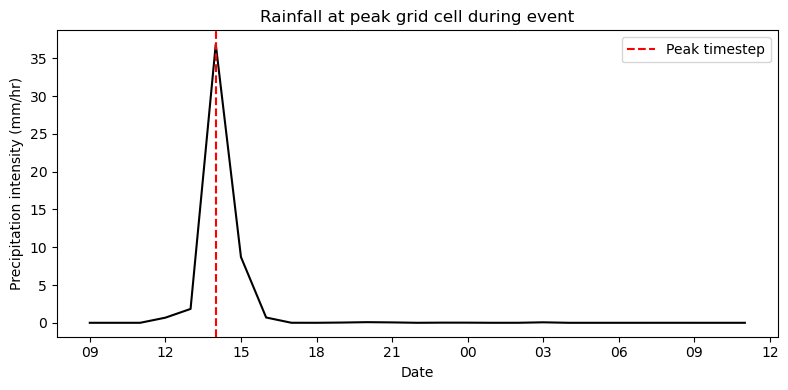

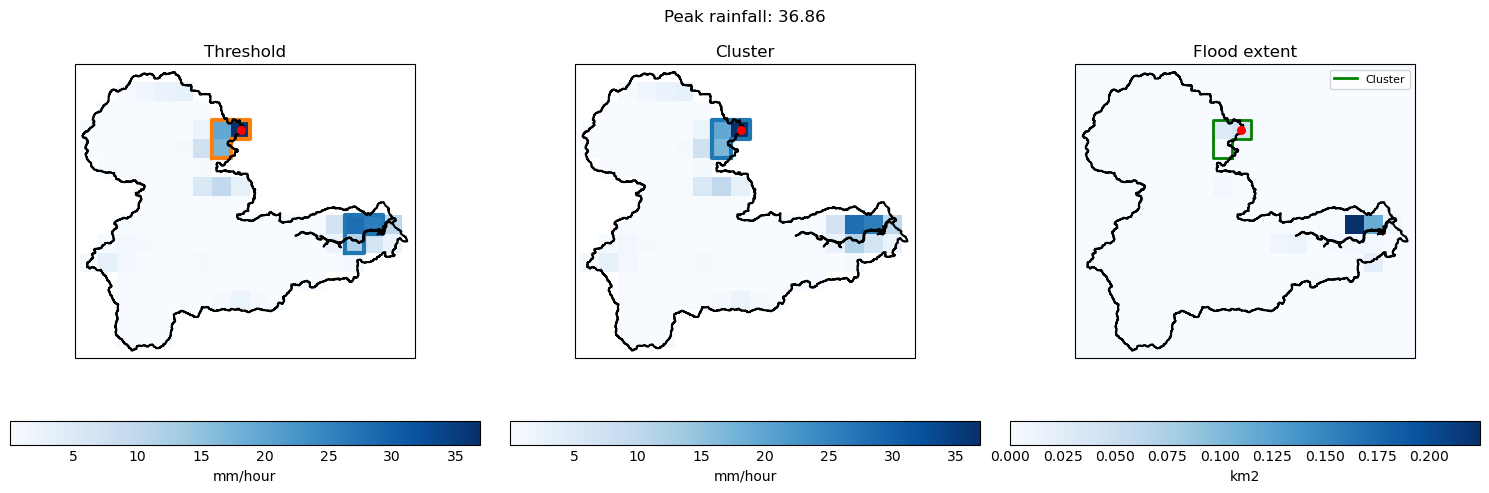

Processing events (serial):  20%|███████████████████▊                                                                               | 1/5 [00:27<01:50, 27.61s/it]

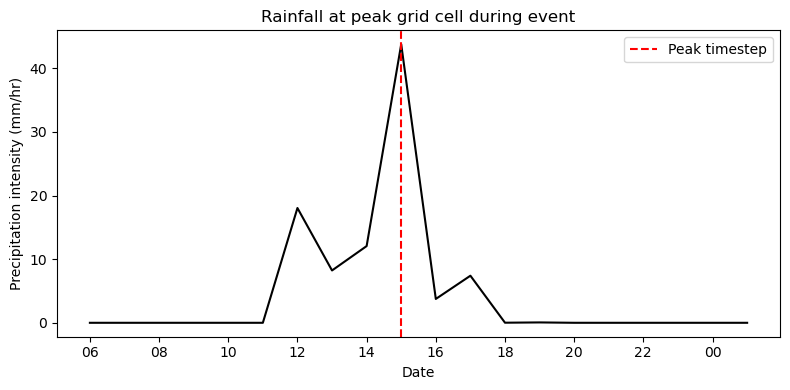

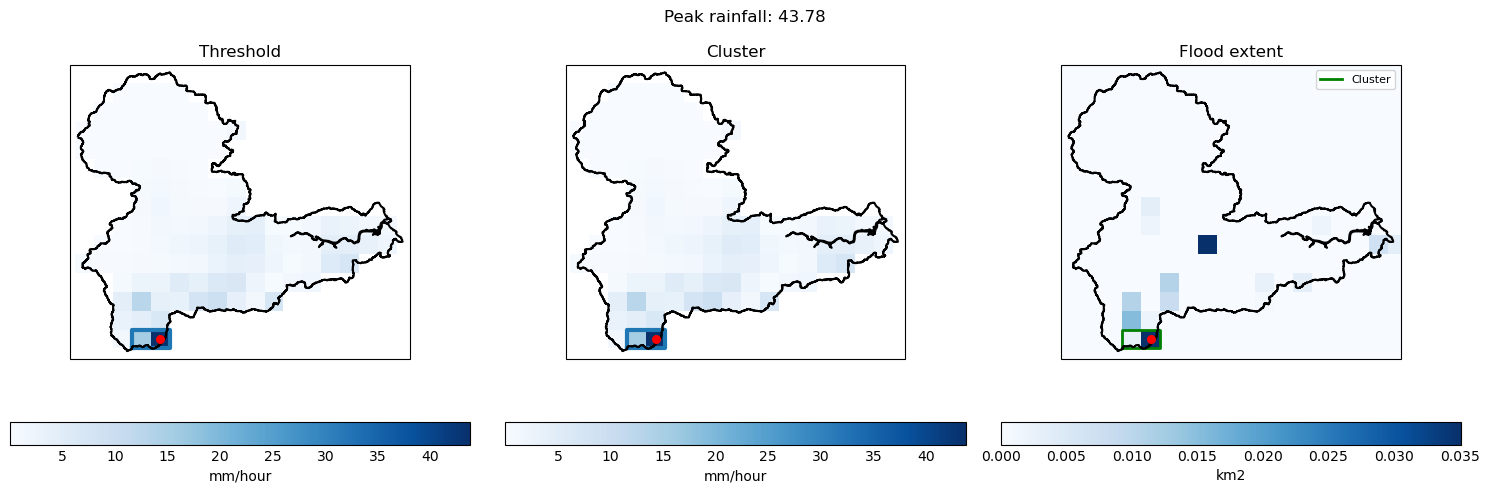

Processing events (serial):  40%|███████████████████████████████████████▌                                                           | 2/5 [00:55<01:22, 27.52s/it]

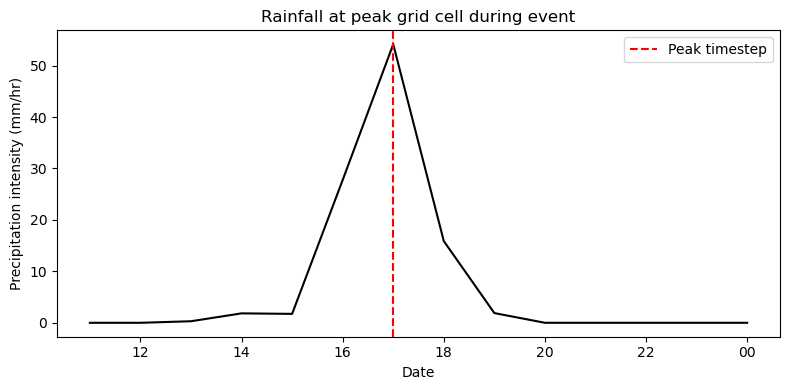

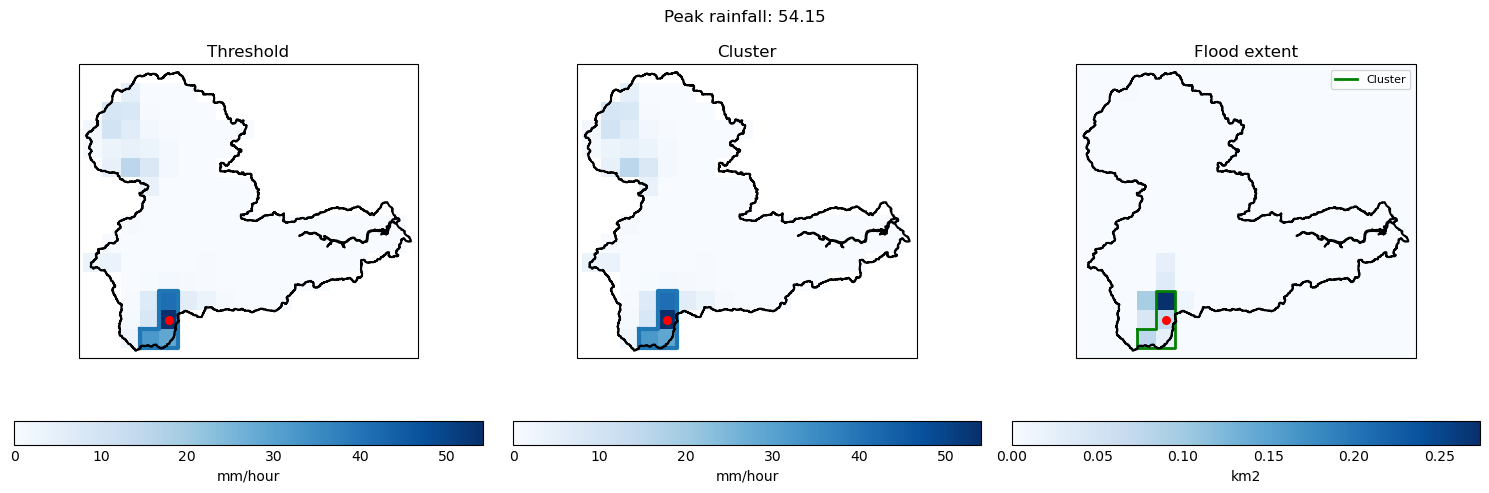

Processing events (serial):  60%|███████████████████████████████████████████████████████████▍                                       | 3/5 [01:03<00:37, 18.88s/it]

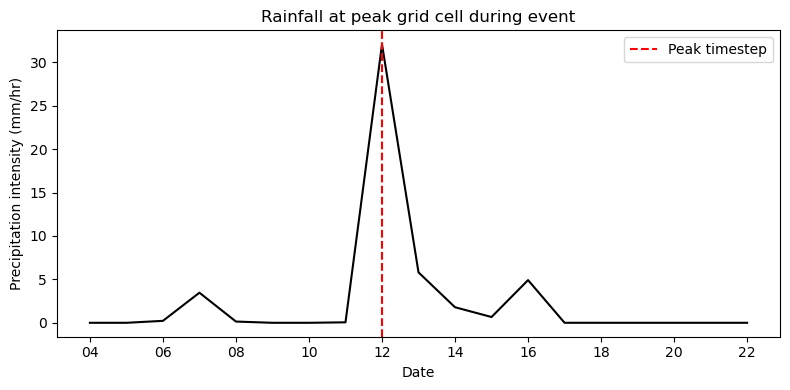

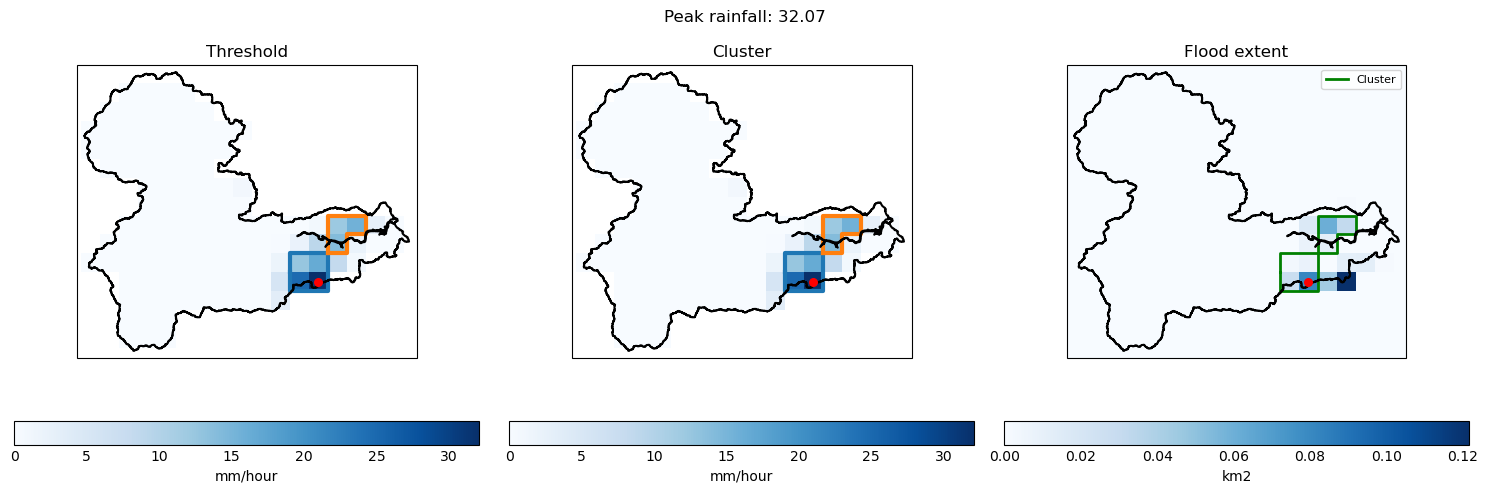

Processing events (serial):  80%|███████████████████████████████████████████████████████████████████████████████▏                   | 4/5 [01:31<00:22, 22.27s/it]

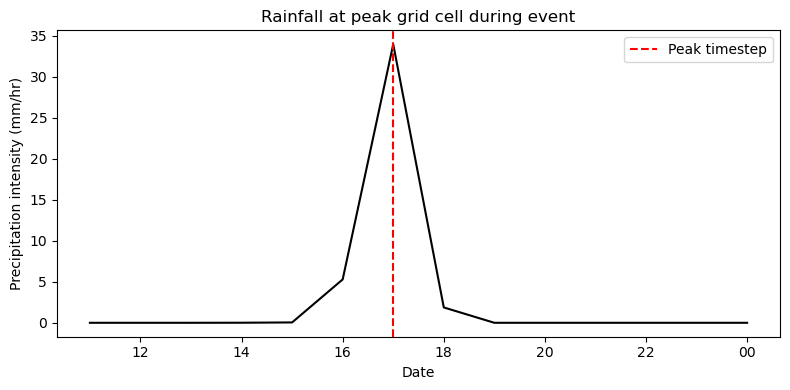

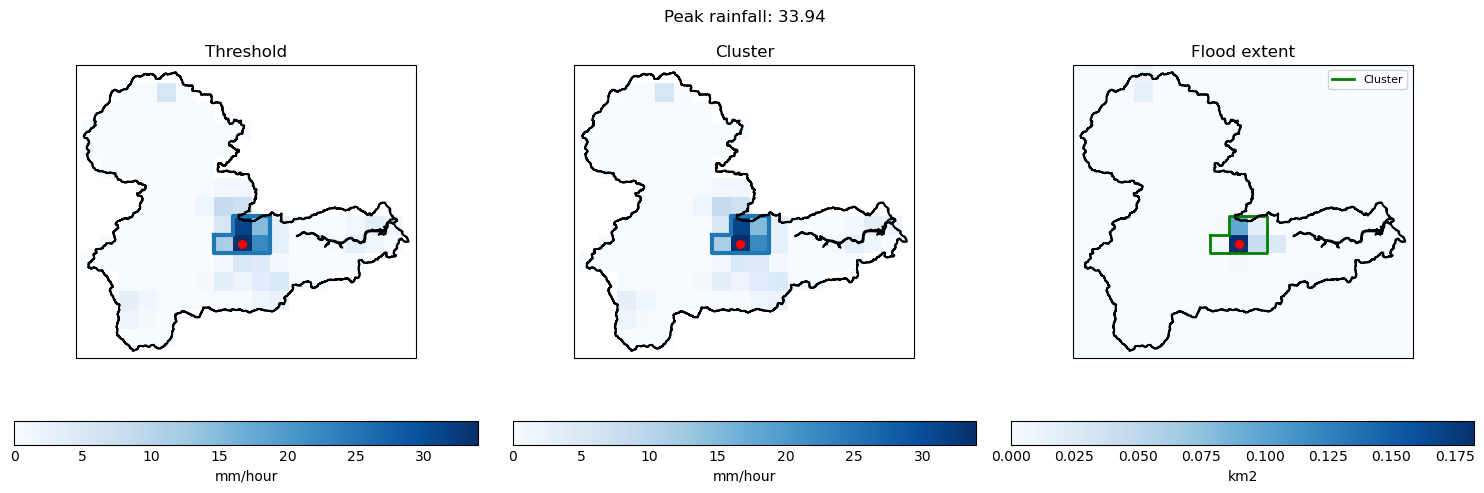

Processing events (serial): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:58<00:00, 23.73s/it]


In [4]:
ens = '15'
if __name__ == "__main__":

    all_results = []

    # ✅ Define paths PER ensemble
    rainfall_cube_dir = f'/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens}/'
    flood_dir = f"/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/Ens{ens}_23/"
    sm_dir = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'

    # ✅ Load events PER ensemble
    rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{CATCHMENT_NAME}_{ens}_full_events_with_event_nums.csv")

    event_nums_to_process = range(1, len(rainfall_events))

    results = process_events_serial_fast(
        event_nums        = range(60,65),
        rainfall_events        = rainfall_events,
        boundary_gdf      = boundary_gdf,
        rainfall_cube_dir = rainfall_cube_dir,
        sm_dir            = sm_dir,
        flood_dir         = flood_dir,
        ens_num           = ens,
        method            = METHOD,
        threshold_level   = THRESHOLD_LEVEL,
        plot_spatial = True, plot_temporal=True)

    results["ensemble"] = ens

    # ✅ Save per ensemble (good practice)
#         results.to_csv(f"results_ens_{ens}.csv", index=False)

    all_results.append(results)

final_results = pd.concat(all_results, ignore_index=True)
#     final_results.to_csv("results_all_ensembles.csv", index=False)